In [101]:
import torch
import math
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import medmnist
from medmnist import INFO
import torch.optim as optim

## part 1 GAN Genrator and discrimnator

In [102]:
'''
sin and noise curve data using math
'''
def get_sine_data(samples=1000):
    x = (torch.rand(samples, 1) * 10) - 5
    y = torch.sin(x)
    return torch.cat((x, y), dim=1)

# 2. Noisy Parametric Curve Data
def get_noisy_curve_data(samples=1000):
    x = (torch.rand(samples, 1) * 10) - 5
    noise = torch.randn(samples, 1) * 0.1
    y = torch.sin(2 * x) + 0.3 * torch.cos(5 * x) + noise
    return torch.cat((x, y), dim=1)

In [103]:
#generator and catcher
import torch.nn as nn

class ModifiedGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 2) # Outputs 2D (x, y)
        )

    def forward(self, z):
        return self.model(z)

class ModifiedDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [104]:
def train_gan(epochs=5000, batch_size=64):
    generator = ModifiedGenerator()
    discriminator = ModifiedDiscriminator()

    criterion = nn.BCELoss()
    opt_g = torch.optim.Adam(generator.parameters(), lr=0.001)
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=0.001)

    for epoch in range(epochs):

        real_data = get_noisy_curve_data(batch_size)
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        opt_d.zero_grad()

        out_real = discriminator(real_data)
        loss_d_real = criterion(out_real, real_labels)

        z = torch.randn(batch_size, 2)
        fake_data = generator(z).detach()
        out_fake = discriminator(fake_data)
        loss_d_fake = criterion(out_fake, fake_labels)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        opt_d.step()


        opt_g.zero_grad()
        z = torch.randn(batch_size, 2)
        fake_data = generator(z)
        out_fake = discriminator(fake_data)


        loss_g = criterion(out_fake, real_labels)
        loss_g.backward()
        opt_g.step()
    return generator

In [105]:
def plot_gan_results(generator, num_samples=1000):

    real_data = get_noisy_curve_data(num_samples).numpy()
    z = torch.randn(num_samples, 2)
    with torch.no_grad():
        fake_data = generator(z).numpy()
    plt.figure(figsize=(10, 6))
    plt.scatter(real_data[:, 0], real_data[:, 1], color='blue', alpha=0.5, label='Real Data', s=10)
    plt.scatter(fake_data[:, 0], fake_data[:, 1], color='red', alpha=0.5, label='Generated (Fake) Data', s=10)
    plt.title('GAN Results: Real vs. Generated Noisy Curve')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True)
    return plt.show()


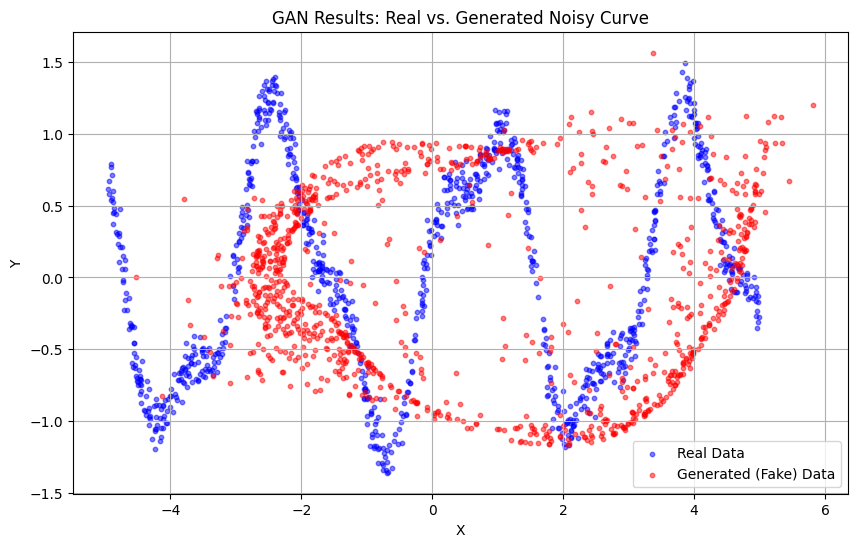

In [106]:
generator=train_gan()
plot_gan_results(generator)

## part 2.1 medmist data

In [107]:
info = INFO['bloodmnist']
DataClass = getattr(medmnist, info['python_class'])

transform = transforms.Compose([
    transforms.Resize(32), # Resize for standard DCGAN
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = DataClass(split='train', transform=transform, download=True)
dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Using device: cuda
Starting Training Loop...
[1/50] Loss_D: 0.8392 Loss_G: 4.9988
[2/50] Loss_D: 3.2686 Loss_G: 2.6925
[3/50] Loss_D: 0.0474 Loss_G: 7.5849
[4/50] Loss_D: 0.0101 Loss_G: 6.0239
[5/50] Loss_D: 0.4559 Loss_G: 2.7599
[6/50] Loss_D: 0.0070 Loss_G: 4.0246
[7/50] Loss_D: 0.0977 Loss_G: 3.5612
[8/50] Loss_D: 0.0748 Loss_G: 3.1334
[9/50] Loss_D: 0.7805 Loss_G: 3.4184
[10/50] Loss_D: 0.0049 Loss_G: 10.1730
[11/50] Loss_D: 0.0009 Loss_G: 13.5580
[12/50] Loss_D: 0.4637 Loss_G: 3.9759
[13/50] Loss_D: 0.0833 Loss_G: 8.0158
[14/50] Loss_D: 3.0442 Loss_G: 7.5188
[15/50] Loss_D: 0.0042 Loss_G: 11.5417
[16/50] Loss_D: 0.0023 Loss_G: 7.5402
[17/50] Loss_D: 0.2655 Loss_G: 8.3750
[18/50] Loss_D: 1.3538 Loss_G: 8.3092
[19/50] Loss_D: 0.0895 Loss_G: 3.7078
[20/50] Loss_D: 0.4549 Loss_G: 3.1511
[21/50] Loss_D: 0.0084 Loss_G: 13.5812
[22/50] Loss_D: 0.0021 Loss_G: 7.0150
[23/50] Loss_D: 0.0016 Loss_G: 8.7241
[24/50] Loss_D: 0.3624 Loss_G: 2.8025
[25/50] Loss_D: 0.1250 Loss_G: 4.3661
[26/50] Lo

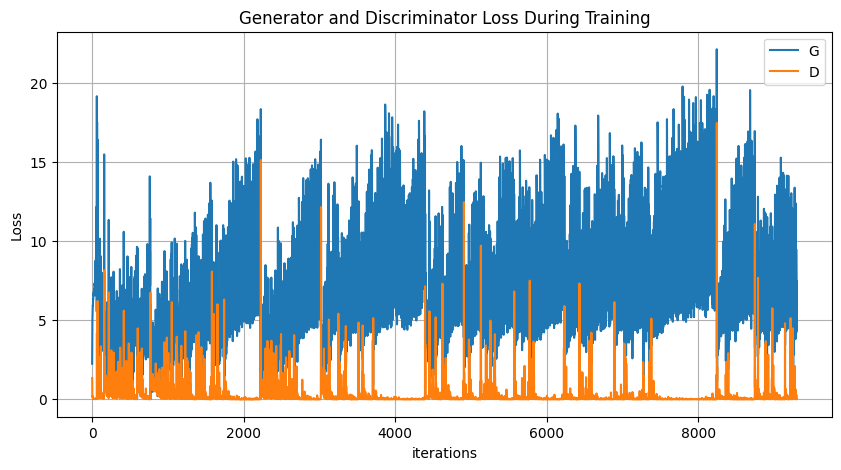

NameError: name 'vutils' is not defined

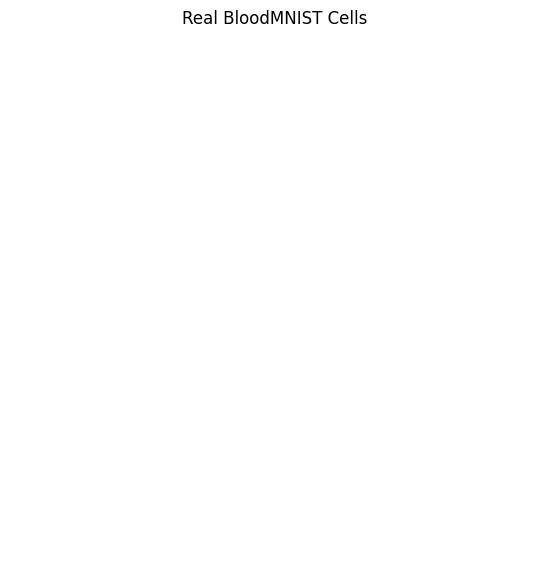

In [108]:
Z_DIM = 100
BATCH_SIZE = 64
LR = 0.0002
EPOCHS = 50
BETA1 = 0.5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{DEVICE}")
info = INFO['bloodmnist']
DataClass = getattr(medmnist, info['python_class'])
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = DataClass(split='train', transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
class Generator(nn.Module):
    def __init__(self, z_dim):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False), # 3 channels for RGB
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 128, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1).squeeze(1)
netG = Generator(Z_DIM).to(DEVICE)
netD = Discriminator().to(DEVICE)
criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))
fixed_noise = torch.randn(64, Z_DIM, 1, 1, device=DEVICE)
G_losses = []
D_losses = []
print("Starting Training Loop...")
for epoch in range(EPOCHS):
    for i, (real_images, _) in enumerate(dataloader):
        real_images = real_images.to(DEVICE)
        b_size = real_images.size(0)
        real_label = torch.ones(b_size, dtype=torch.float, device=DEVICE)
        fake_label = torch.zeros(b_size, dtype=torch.float, device=DEVICE)
        netD.zero_grad()
        output_real = netD(real_images)
        errD_real = criterion(output_real, real_label)
        errD_real.backward()
        noise = torch.randn(b_size, Z_DIM, 1, 1, device=DEVICE)
        fake_images = netG(noise)
        output_fake = netD(fake_images.detach())
        errD_fake = criterion(output_fake, fake_label)
        errD_fake.backward()

        optimizerD.step()
        errD = errD_real + errD_fake
        netG.zero_grad()
        output_fake_for_G = netD(fake_images)
        errG = criterion(output_fake_for_G, real_label)
        errG.backward()
        optimizerG.step()
        G_losses.append(errG.item())
        D_losses.append(errD.item())
print(f'[{epoch+1}/{EPOCHS}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}')
print("Training Complete. Generating Visualizations...")
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
real_batch = next(iter(dataloader))[0].to(DEVICE)
with torch.no_grad():
    fake_batch = netG(fixed_noise).detach().cpu()

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real BloodMNIST Cells")
real_grid = vutils.make_grid(real_batch[:64], padding=2, normalize=True)
plt.imshow(np.transpose(real_grid.cpu(), (1, 2, 0)))

# Display Fake Images
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Generated (Fake) Blood Cells")
fake_grid = vutils.make_grid(fake_batch[:64], padding=2, normalize=True)
plt.imshow(np.transpose(fake_grid, (1, 2, 0)))

plt.show()

## part 2.2  security

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [110]:
df = pd.read_csv('Wednesday-workingHours.pcap_ISCX.csv')
df.columns = df.columns.str.strip()
df = df.replace([np.inf, -np.inf], np.nan).dropna()
labels = df['Label']
features = df.drop(columns=['Label'])
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_features = scaler.fit_transform(features)
tensor_data = torch.tensor(scaled_features, dtype=torch.float32)
dataset = TensorDataset(tensor_data)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)
input_dim = features.shape[1]
print(f"Feature Dimension: {input_dim}")

Feature Dimension: 78


In [111]:
class TabularGenerator(nn.Module):
    def __init__(self, z_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, out_dim),
            nn.Tanh()
        )

    def forward(self, x): return self.net(x)
class TabularDiscriminator(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x): return self.net(x)

In [113]:
import torch.optim as optim

Z_DIM = 64
EPOCHS = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = TabularGenerator(Z_DIM, input_dim).to(DEVICE)
D = TabularDiscriminator(input_dim).to(DEVICE)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

G_losses, D_losses = [], []

for epoch in range(EPOCHS):
    for batch in dataloader:
        real_data = batch[0].to(DEVICE)
        b_size = real_data.size(0)

        real_labels = torch.ones(b_size, 1).to(DEVICE)
        fake_labels = torch.zeros(b_size, 1).to(DEVICE)
        opt_D.zero_grad()
        out_real = D(real_data)
        loss_D_real = criterion(out_real, real_labels)

        z = torch.randn(b_size, Z_DIM).to(DEVICE)
        fake_data = G(z)
        out_fake = D(fake_data.detach())
        loss_D_fake = criterion(out_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()
        opt_G.zero_grad()
        out_fake_G = D(fake_data)
        loss_G = criterion(out_fake_G, real_labels)
        loss_G.backward()
        opt_G.step()

    G_losses.append(loss_G.item())
    D_losses.append(loss_D.item())
    print(f"Epoch {epoch+1}/{EPOCHS} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

Epoch 1/30 | D Loss: 1.3211 | G Loss: 0.8092
Epoch 2/30 | D Loss: 1.3646 | G Loss: 0.7241
Epoch 3/30 | D Loss: 1.3427 | G Loss: 0.7568
Epoch 4/30 | D Loss: 1.3607 | G Loss: 0.7625
Epoch 5/30 | D Loss: 1.3781 | G Loss: 0.7370
Epoch 6/30 | D Loss: 1.3420 | G Loss: 0.8574
Epoch 7/30 | D Loss: 1.3316 | G Loss: 0.7642
Epoch 8/30 | D Loss: 1.3055 | G Loss: 0.7678
Epoch 9/30 | D Loss: 1.3008 | G Loss: 0.8018
Epoch 10/30 | D Loss: 1.3112 | G Loss: 0.8210
Epoch 11/30 | D Loss: 1.2951 | G Loss: 0.8618
Epoch 12/30 | D Loss: 1.3340 | G Loss: 0.7551
Epoch 13/30 | D Loss: 1.2858 | G Loss: 0.8994
Epoch 14/30 | D Loss: 1.2487 | G Loss: 0.9543
Epoch 15/30 | D Loss: 1.2930 | G Loss: 0.8408
Epoch 16/30 | D Loss: 1.2744 | G Loss: 0.8661
Epoch 17/30 | D Loss: 1.2612 | G Loss: 1.0587
Epoch 18/30 | D Loss: 1.2773 | G Loss: 0.9786
Epoch 19/30 | D Loss: 1.2360 | G Loss: 1.0766
Epoch 20/30 | D Loss: 1.1956 | G Loss: 0.9835
Epoch 21/30 | D Loss: 1.3149 | G Loss: 0.8926
Epoch 22/30 | D Loss: 1.3149 | G Loss: 0.88

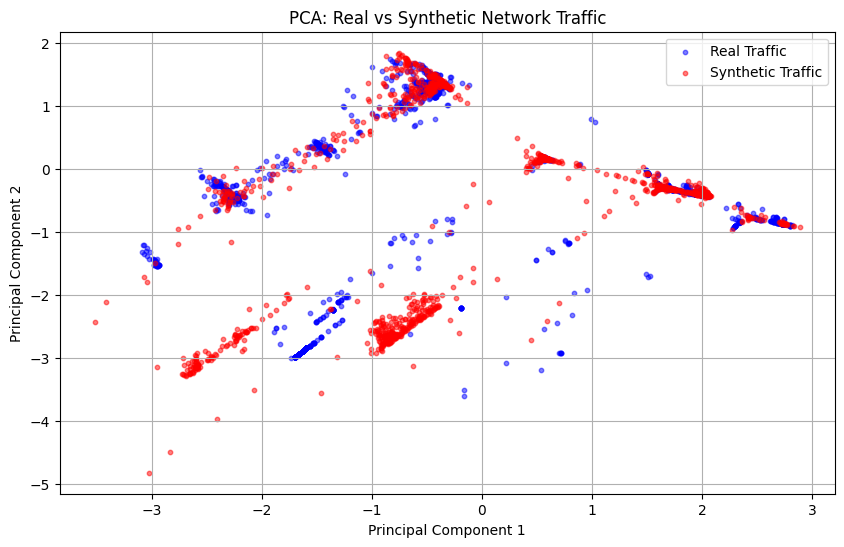

In [114]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
z = torch.randn(2000, Z_DIM).to(DEVICE)
with torch.no_grad():
    generated_samples = G(z).cpu().numpy()
real_samples = tensor_data[:2000].numpy()
pca = PCA(n_components=2)
pca.fit(real_samples)
real_pca = pca.transform(real_samples)
fake_pca = pca.transform(generated_samples)
plt.figure(figsize=(10, 6))
plt.scatter(real_pca[:, 0], real_pca[:, 1], color='blue', alpha=0.5, label='Real Traffic', s=10)
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], color='red', alpha=0.5, label='Synthetic Traffic', s=10)
plt.title("PCA: Real vs Synthetic Network Traffic")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

## Part 2.3 quick pizza  draw dataset  

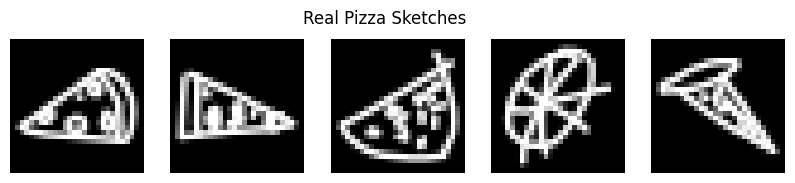

In [115]:
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pizza.npy"
urllib.request.urlretrieve(url, "pizza.npy")
data = np.load("pizza.npy")
data = (data.astype(np.float32) - 127.5) / 127.5
data = data.reshape(-1, 1, 28, 28)
tensor_x = torch.Tensor(data[:50000])
dataset = TensorDataset(tensor_x)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)
def show_images(images, title="Samples"):
    fig, axes = plt.subplots(1, 5, figsize=(10, 2))
    for i, ax in enumerate(axes):
        ax.imshow((images[i][0] + 1) / 2, cmap='gray')
        ax.axis('off')
    plt.suptitle(title)
    plt.show()

show_images(tensor_x[:5], "Real Pizza Sketches")